C:\Users\vivek\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Train : (14448, 7)
Val   : (4953, 7)
Test  : (1239, 7)
Training Linear Regression...
Linear Regression → RMSE: 0.725, R2: 0.593

Training Decision Tree...
Decision Tree → RMSE: 0.633, R2: 0.690

Training Random Forest...


C:\Users\vivek\anaconda4\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Random Forest → RMSE: 0.506, R2: 0.802

Training XGBoost...


C:\Users\vivek\anaconda4\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


XGBoost → RMSE: 0.451, R2: 0.843

Validation Results:
                       RMSE        R2
Linear Regression  0.725420  0.593126
Decision Tree      0.633194  0.690005
Random Forest      0.505683  0.802286
XGBoost            0.450712  0.842935
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}
Validation RMSE after Grid Search: 0.442
Validation R² after Grid Search: 0.849
Final Test Set Evaluation:
Test RMSE: 0.451
Test R²: 0.853


C:\Users\vivek\anaconda4\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\vivek\anaconda4\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


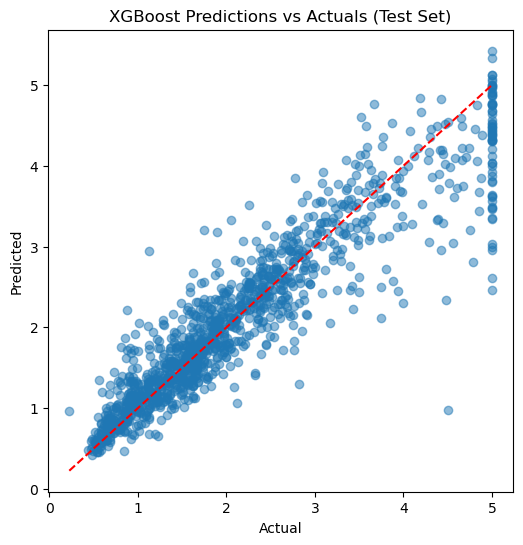

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


california_housing = fetch_california_housing()
df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
df["Target"] = california_housing.target

X = df.drop(["Target", "AveBedrms"], axis=1)
y = df["Target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)


models = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),  # optional, tree models don’t require scaling
        ('model', DecisionTreeRegressor(max_depth=10, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective='reg:squarederror'
        ))
    ])
}

results = {}
for name, pipeline in models.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    rmse = mean_squared_error(y_val, val_pred, squared=False)
    r2 = r2_score(y_val, val_pred)
    results[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name} → RMSE: {rmse:.3f}, R2: {r2:.3f}\n")

results_df = pd.DataFrame(results).T
print("Validation Results:")
print(results_df)

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(
        objective='reg:squarederror', random_state=42, n_jobs=-1
    ))
])

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

val_pred = best_model.predict(X_val)
rmse_val = mean_squared_error(y_val, val_pred, squared=False)
r2_val = r2_score(y_val, val_pred)

print(f"Validation RMSE after Grid Search: {rmse_val:.3f}")
print(f"Validation R² after Grid Search: {r2_val:.3f}")


y_test_pred = best_model.predict(X_test)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
test_r2 = r2_score(y_test, y_test_pred)

print("Final Test Set Evaluation:")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test R²: {test_r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predictions vs Actuals (Test Set)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


## Below its without train/val/test split & using cross val instead


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

california_housing = fetch_california_housing()
df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
df["Target"] = california_housing.target

X = df.drop(["Target", "AveBedrms"], axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


models = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),  
        ('model', DecisionTreeRegressor(max_depth=10, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective='reg:squarederror'
        ))
    ])
}

cv_results = {}
for name, pipeline in models.items():
    print(f"Cross-validating {name}...")
    # Negative RMSE for cross_val_score, then convert to positive
    neg_rmse_scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    mean_rmse = -np.mean(neg_rmse_scores)
    
    r2_scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='r2',
        cv=5,
        n_jobs=-1
    )
    mean_r2 = np.mean(r2_scores)
    
    cv_results[name] = {"RMSE": mean_rmse, "R2": mean_r2}
    print(f"{name} → CV RMSE: {mean_rmse:.3f}, CV R²: {mean_r2:.3f}\n")

cv_results_df = pd.DataFrame(cv_results).T
print("Cross-Validation Results:")
print(cv_results_df)

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters from Grid Search:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_test_pred = best_model.predict(X_test)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
test_r2 = r2_score(y_test, y_test_pred)

print("Final Test Set Evaluation:")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test R²: {test_r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predictions vs Actuals (Test Set)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()
